#### **K-Nearest Neighbors (KNN) — Four Practical Labs**

This notebook contains four classroom-ready labs for teaching KNN:

1. **KNN classification and decision boundaries**
2. **Effect of feature scaling on KNN**
3. **Choosing the best \(k\) and distance metric with cross-validation**
4. **KNN on high-dimensional data with PCA**

The notebook uses standard `scikit-learn`, `numpy`, `pandas`, and `matplotlib` datasets and does not require internet access.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine, load_digits, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


#### **Lab 1 — KNN Classification and Decision Boundaries**

##### **Goal**

Use KNN on the Iris dataset and visualize how the decision boundary changes with different values of \(k\).

#### **Learning objectives**

- Train a basic KNN classifier.
- Understand how \(k\) affects model flexibility.
- Visualize decision regions in 2D.


In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data[:, [0, 2]]  # sepal length and petal length for visualization
y = iris.target

feature_names = [iris.feature_names[i] for i in [0, 2]]
target_names = iris.target_names

df_iris = pd.DataFrame(X, columns=feature_names)
df_iris["target"] = y
df_iris["species"] = [target_names[i] for i in y]

df_iris.head()


,sepal length (cm),petal length (cm),target,species
0,5.1,1.4,0,setosa
1,4.9,1.4,0,setosa
2,4.7,1.3,0,setosa
3,4.6,1.5,0,setosa
4,5.0,1.4,0,setosa


In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (112, 2)
Test shape: (38, 2)


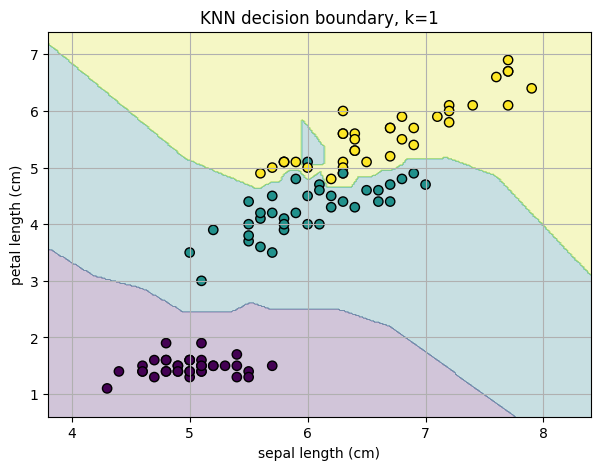

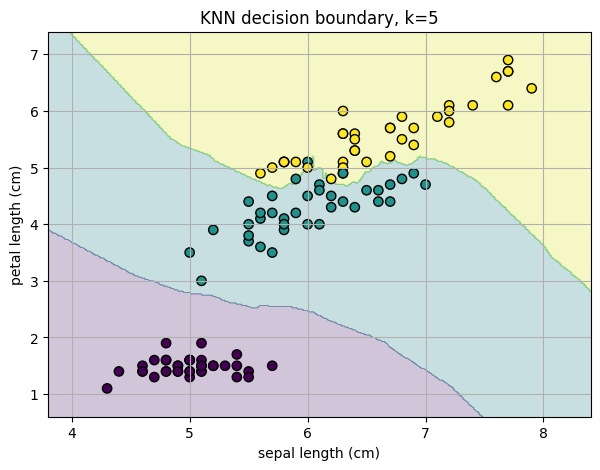

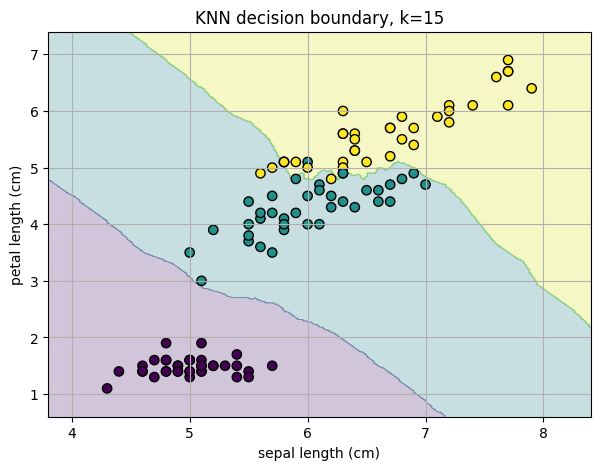

In [4]:
def plot_knn_decision_boundary(X, y, k=5, title=None):
    # Plot a 2D KNN decision boundary.
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X, y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=45)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title or f"KNN decision boundary, k={k}")
    plt.show()

for k in [1, 5, 15]:
    plot_knn_decision_boundary(X_train, y_train, k=k)


In [5]:
# Evaluate different k values on the test set
for k in [1, 3, 5, 15]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"k={k:2d} | Test accuracy: {accuracy_score(y_test, y_pred):.3f}")


k= 1 | Test accuracy: 0.868
k= 3 | Test accuracy: 0.895
k= 5 | Test accuracy: 0.868
k=15 | Test accuracy: 0.921


#### **Questions for students**

1. What happens to the decision boundary when \(k=1\)?
2. Why does a larger \(k\) usually produce a smoother decision boundary?
3. Which value of \(k\) would you choose here, and why?


#### **Lab 2 — Effect of Feature Scaling on KNN**

##### **Goal**

Show that KNN is sensitive to feature scaling because it is based on distances.

##### **Learning objectives**

- Understand why scale matters for distance-based models.
- Compare KNN with and without standardization.
- Interpret the effect of variables measured on different scales.


In [6]:
# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

df_wine = pd.DataFrame(X, columns=wine.feature_names)
df_wine["target"] = y

df_wine.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
# Inspect feature ranges
feature_ranges = pd.DataFrame({
    "feature": wine.feature_names,
    "min": X.min(axis=0),
    "max": X.max(axis=0),
    "range": X.max(axis=0) - X.min(axis=0)
}).sort_values("range", ascending=False)

feature_ranges.head(10)


,feature,min,max,range
12,proline,278.00,1680.00,1402.00
4,magnesium,70.00,162.00,92.00
3,alcalinity_of_ash,10.60,30.00,19.40
9,color_intensity,1.28,13.00,11.72
1,malic_acid,0.74,5.80,5.06
6,flavanoids,0.34,5.08,4.74
0,alcohol,11.03,14.83,3.80
8,proanthocyanins,0.41,3.58,3.17
5,total_phenols,0.98,3.88,2.90
11,od280/od315_of_diluted_wines,1.27,4.00,2.73


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# KNN without scaling
knn_no_scaling = KNeighborsClassifier(n_neighbors=5)
knn_no_scaling.fit(X_train, y_train)
pred_no_scaling = knn_no_scaling.predict(X_test)

# KNN with scaling
knn_with_scaling = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_with_scaling.fit(X_train, y_train)
pred_with_scaling = knn_with_scaling.predict(X_test)

print("Accuracy without scaling:", accuracy_score(y_test, pred_no_scaling))
print("Accuracy with scaling:   ", accuracy_score(y_test, pred_with_scaling))


Accuracy without scaling: 0.7777777777777778
Accuracy with scaling:    0.9333333333333333


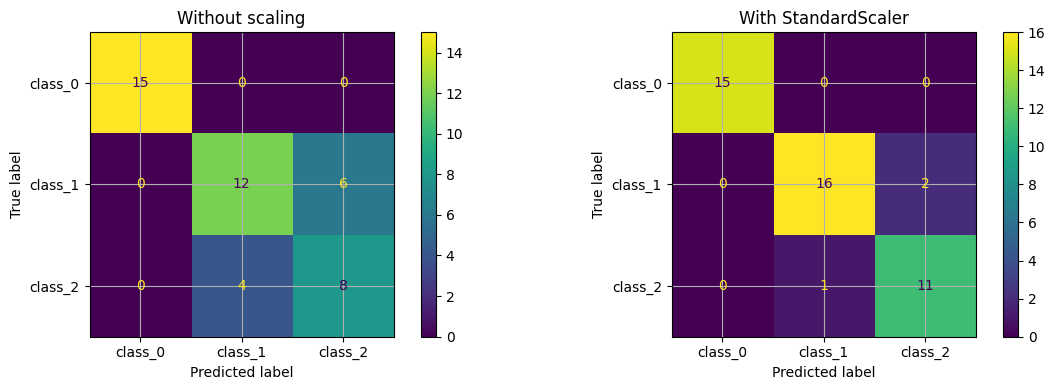

In [9]:
# Compare confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_no_scaling, display_labels=wine.target_names, ax=axes[0]
)
axes[0].set_title("Without scaling")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_with_scaling, display_labels=wine.target_names, ax=axes[1]
)
axes[1].set_title("With StandardScaler")

plt.tight_layout()
plt.show()


In [10]:
print("Classification report with scaling:")
print(classification_report(y_test, pred_with_scaling, target_names=wine.target_names))


Classification report with scaling:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.94      0.89      0.91        18
     class_2       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



#### **Questions for students**

1. Which features have the largest numerical ranges?
2. Why can large-scale features dominate Euclidean distance?
3. Is scaling always necessary for KNN? When might it not be?


#### **Lab 3 — Choosing the Best \(k\) and Distance Metric**

##### **Goal**

Use cross-validation to choose the best number of neighbors and distance metric.

##### **Learning objectives**

- Use cross-validation to avoid choosing \(k\) arbitrarily.
- Compare Euclidean, Manhattan, and Minkowski distances.
- Understand the bias-variance tradeoff in KNN.


In [11]:
# Use the Wine dataset again
X = wine.data
y = wine.target

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X, y)

print("Best parameters:")
print(grid.best_params_)
print(f"Best cross-validation accuracy: {grid.best_score_:.3f}")


Best parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}
Best cross-validation accuracy: 0.978


In [12]:
# Convert CV results into a dataframe
results = pd.DataFrame(grid.cv_results_)

cols = [
    "param_knn__n_neighbors",
    "param_knn__weights",
    "param_knn__metric",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]

results_summary = results[cols].sort_values("mean_test_score", ascending=False)
results_summary.head(10)


,param_knn__n_neighbors,param_knn__weights,param_knn__metric,mean_test_score,std_test_score,mean_train_score
80,11,uniform,manhattan,0.977619,0.020832,0.985955
81,11,distance,manhattan,0.977619,0.020832,1.000000
12,7,uniform,euclidean,0.966508,0.020747,0.970501
42,22,uniform,euclidean,0.966508,0.027186,0.976145
38,20,uniform,euclidean,0.966508,0.027186,0.971920
85,13,distance,manhattan,0.966508,0.032369,1.000000
86,14,uniform,manhattan,0.966508,0.032369,0.978942
87,14,distance,manhattan,0.966508,0.032369,1.000000
88,15,uniform,manhattan,0.966508,0.032369,0.978942
89,15,distance,manhattan,0.966508,0.032369,1.000000


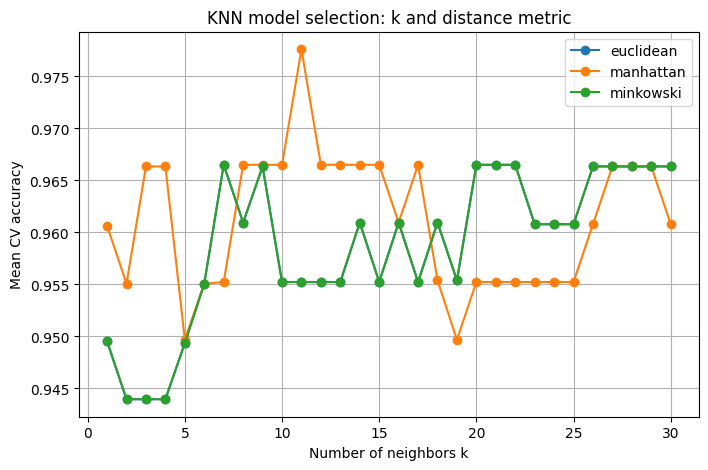

In [13]:
# Plot accuracy versus k for each metric using uniform weights
plot_df = results[(results["param_knn__weights"] == "uniform")].copy()

plt.figure(figsize=(8, 5))

for metric in plot_df["param_knn__metric"].unique():
    sub = plot_df[plot_df["param_knn__metric"] == metric]
    sub = sub.sort_values("param_knn__n_neighbors")
    plt.plot(
        sub["param_knn__n_neighbors"],
        sub["mean_test_score"],
        marker="o",
        label=metric
    )

plt.xlabel("Number of neighbors k")
plt.ylabel("Mean CV accuracy")
plt.title("KNN model selection: k and distance metric")
plt.legend()
plt.show()


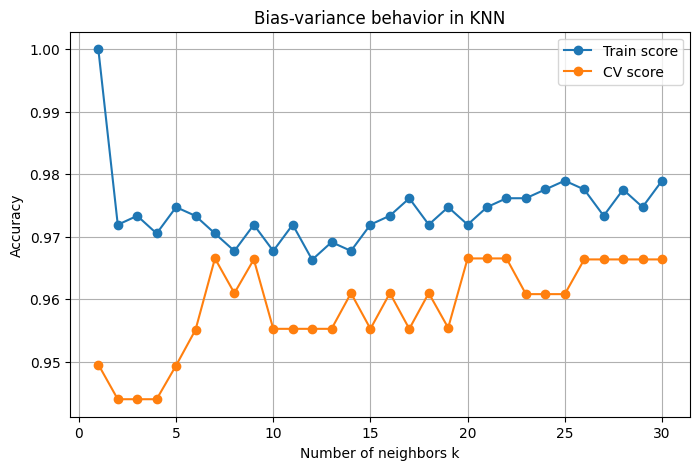

In [14]:
# Compare train and validation score for one metric
metric = "euclidean"
weights = "uniform"

sub = results[
    (results["param_knn__metric"] == metric) &
    (results["param_knn__weights"] == weights)
].copy().sort_values("param_knn__n_neighbors")

plt.figure(figsize=(8, 5))
plt.plot(sub["param_knn__n_neighbors"], sub["mean_train_score"], marker="o", label="Train score")
plt.plot(sub["param_knn__n_neighbors"], sub["mean_test_score"], marker="o", label="CV score")
plt.xlabel("Number of neighbors k")
plt.ylabel("Accuracy")
plt.title("Bias-variance behavior in KNN")
plt.legend()
plt.show()


### Questions for students

1. Which value of \(k\) is selected by cross-validation?
2. What happens when \(k\) is very small?
3. What happens when \(k\) becomes too large?
4. Did the best model use uniform or distance-based weighting?


#### **Lab 4 — KNN on High-Dimensional Data with PCA**

##### **Goal**

Apply KNN to the Digits dataset and test whether PCA helps.

##### **Learning objectives**

- Understand KNN in higher-dimensional spaces.
- Use PCA as a preprocessing step.
- Compare accuracy and computational cost with and without dimensionality reduction.


Data shape: (1797, 64)
Each image has 64 features.


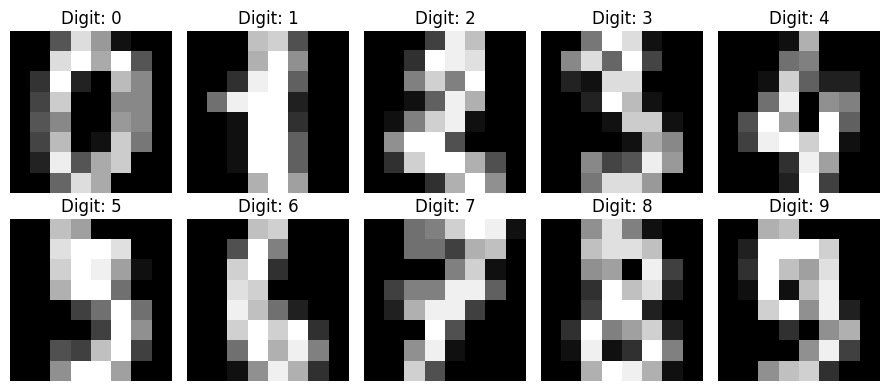

In [15]:
# Load digits dataset: 8x8 images of handwritten digits
digits = load_digits()
X = digits.data
y = digits.target

print("Data shape:", X.shape)
print("Each image has", X.shape[1], "features.")

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Baseline KNN without PCA
knn_digits = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_digits.fit(X_train, y_train)
pred_digits = knn_digits.predict(X_test)

print("KNN without PCA accuracy:", accuracy_score(y_test, pred_digits))


KNN without PCA accuracy: 0.9644444444444444


In [17]:
# KNN with PCA
knn_pca_digits = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.90, random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_pca_digits.fit(X_train, y_train)
pred_pca_digits = knn_pca_digits.predict(X_test)

pca_step = knn_pca_digits.named_steps["pca"]

print("KNN with PCA accuracy:", accuracy_score(y_test, pred_pca_digits))
print("Original dimensions:", X_train.shape[1])
print("PCA dimensions retained:", pca_step.n_components_)


KNN with PCA accuracy: 0.9622222222222222
Original dimensions: 64
PCA dimensions retained: 31


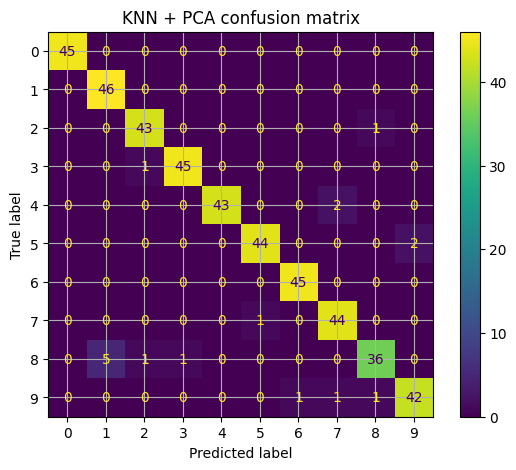

In [18]:
# Confusion matrix for PCA model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_pca_digits,
    display_labels=digits.target_names
)
plt.title("KNN + PCA confusion matrix")
plt.show()


In [19]:
# Study different numbers of PCA components
component_values = [2, 5, 10, 20, 30, 40, 50, 64]
accuracies = []

for n_components in component_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    accuracies.append(scores.mean())

pca_results = pd.DataFrame({
    "n_components": component_values,
    "mean_cv_accuracy": accuracies
})

pca_results


,n_components,mean_cv_accuracy
0,2,0.511975
1,5,0.827478
2,10,0.892606
3,20,0.936582
4,30,0.939918
5,40,0.938812
6,50,0.942143
7,64,0.944362


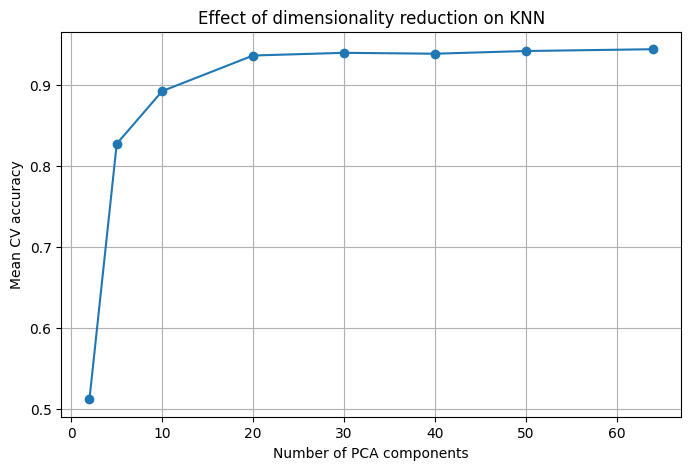

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(pca_results["n_components"], pca_results["mean_cv_accuracy"], marker="o")
plt.xlabel("Number of PCA components")
plt.ylabel("Mean CV accuracy")
plt.title("Effect of dimensionality reduction on KNN")
plt.show()


### Questions for students

1. Does PCA improve or reduce accuracy in this case?
2. Why might dimensionality reduction help KNN?
3. Why might too few PCA components hurt performance?
4. What tradeoff exists between accuracy and dimensionality?


##### **Optional Challenge Lab — KNN with Noisy Features**

Add many irrelevant features to a classification problem and observe how KNN performance changes. Then test whether scaling and PCA help.


In [21]:
# Optional challenge: noisy high-dimensional classification
X, y = make_classification(
    n_samples=1200,
    n_features=80,
    n_informative=5,
    n_redundant=5,
    n_repeated=0,
    n_classes=3,
    random_state=RANDOM_STATE
)

models = {
    "KNN raw": KNeighborsClassifier(n_neighbors=5),
    "KNN scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]),
    "KNN scaled + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=10, random_state=RANDOM_STATE)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"{name:18s} | mean CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")


KNN raw            | mean CV accuracy = 0.709 ± 0.027
KNN scaled         | mean CV accuracy = 0.528 ± 0.033
KNN scaled + PCA   | mean CV accuracy = 0.603 ± 0.043


#### **Final Discussion**

KNN is simple and intuitive, but it is highly dependent on:

- the choice of \(k\),
- the distance metric,
- feature scaling,
- dimensionality,
- noise and irrelevant features,
- the local density of the data.

This makes KNN an excellent teaching model for understanding the geometry of machine learning.
